# Cancer Diagnosis - Model Training & Evaluation

## Overview
Building a reproducible ML pipeline to classify tumors as malignant or benign.
Multiple models are trained and compared systematically.

### Models
- Logistic Regression (baseline)
- Random Forest
- Support Vector Machine (SVM)
- Multi-layer Perceptron (MLP)
- K-Nearest Neighbors (KNN)

### Evaluation Metrics
- **Recall (sensitivity)** — prioritized: missing a cancer case is worse than a false alarm
- Precision
- F1-score
- Accuracy
- AUC-ROC

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                              roc_curve, auc)

# Ladda data
data = load_breast_cancer()
X = data.data
y = data.target

print(f"Dataset shape: {X.shape}")
print(f"Classes: {data.target_names}")

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']


## 1. Data Preparation
Splitting data into 80% training and 20% test set using stratified sampling 
to preserve class balance.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

## 2. Model Pipelines
Each model is wrapped in a sklearn Pipeline with StandardScaler — ensuring 
features are normalized before training. This is especially important for 
SVM and MLP which are sensitive to feature scales.

In [3]:
# Building pipelines - scaler + model for every classifyer
pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(random_state=42, probability=True))
    ]),
    'MLP': Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(random_state=42, max_iter=1000))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ])
}

print("Pipelines created!")

Pipelines created!


In [4]:
# Cross-validation for all models
results = {}

for name, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, X_train, y_train, 
                             cv=5, scoring='recall')
    results[name] = {
        'recall_mean': scores.mean(),
        'recall_std': scores.std()
    }
    print(f"{name}: Recall = {scores.mean():.3f} (+/- {scores.std():.3f})")

Logistic Regression: Recall = 0.989 (+/- 0.014)
Random Forest: Recall = 0.968 (+/- 0.020)
SVM: Recall = 0.979 (+/- 0.017)
MLP: Recall = 0.989 (+/- 0.014)
KNN: Recall = 0.982 (+/- 0.016)


In [5]:
# Gather accuracy, recall, precision and F1 with cross-validation
metrics = ['accuracy', 'recall', 'precision', 'f1']
results_full = {}

for name, pipeline in pipelines.items():
    results_full[name] = {}
    for metric in metrics:
        scores = cross_val_score(pipeline, X_train, y_train, 
                                cv=5, scoring=metric)
        results_full[name][metric] = scores.mean()

# Visa som tabell
results_df = pd.DataFrame(results_full).T.round(3)
print(results_df)

                     accuracy  recall  precision     f1
Logistic Regression     0.980   0.989      0.980  0.984
Random Forest           0.954   0.968      0.959  0.963
SVM                     0.971   0.979      0.976  0.977
MLP                     0.978   0.989      0.976  0.983
KNN                     0.967   0.982      0.966  0.974


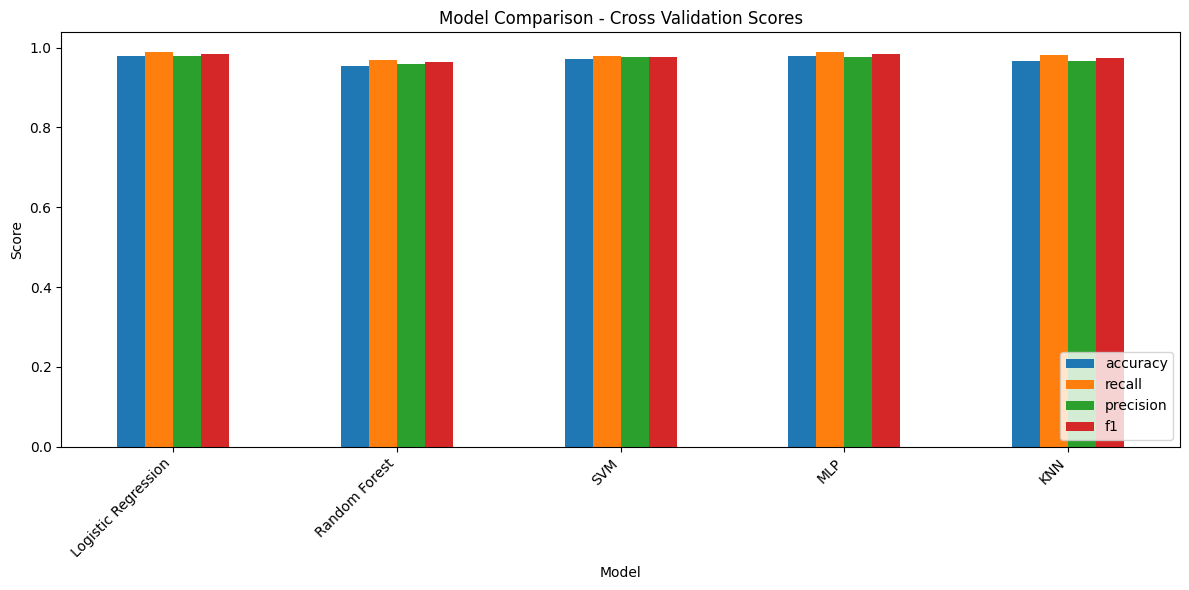

In [6]:
# Ploting the comparisons
results_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Comparison - Cross Validation Scores')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

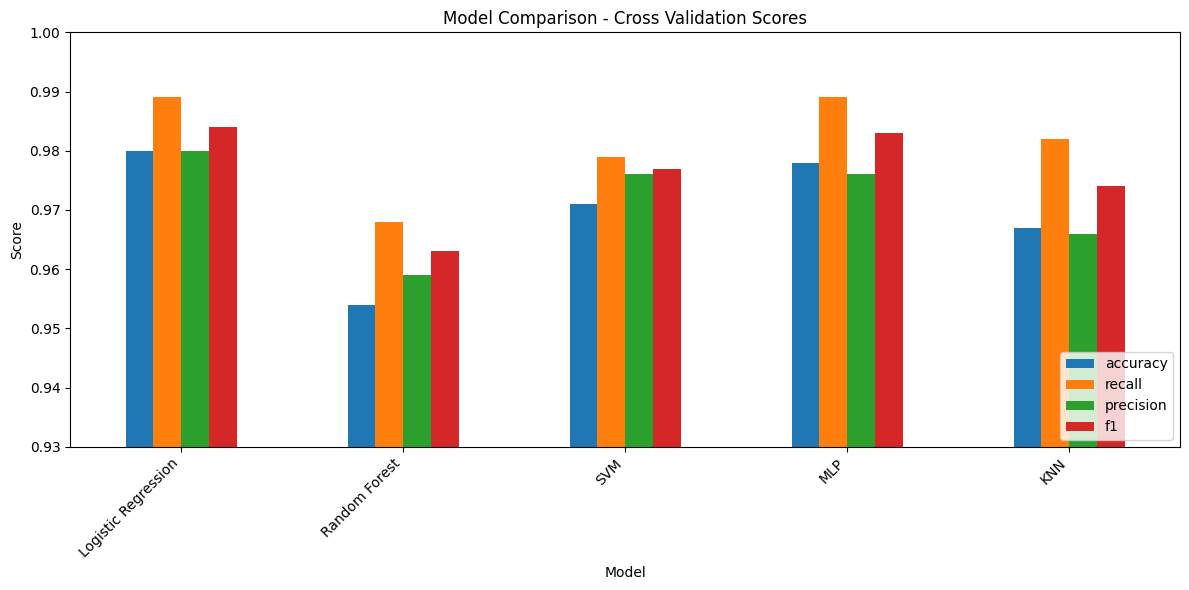

In [7]:
# Plotting comparisons and zoom y-axel
results_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Comparison - Cross Validation Scores')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0.93, 1.0) 
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 3. Model Comparison
5-fold cross-validation on training data. Recall is the primary metric — 
in medical diagnostics, missing a cancer case (false negative) is worse 
than a false alarm (false positive).

Logistic Regression and MLP share the best recall (0.989). Logistic 
Regression is chosen as the final model due to its simplicity and interpretability.

In [11]:
# Train the best model (logistic regression) on the whole training set
best_model = pipelines['Logistic Regression']
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, 
                            target_names=['Malignant', 'Benign'],
                            digits=4))

              precision    recall  f1-score   support

   Malignant     0.9762    0.9762    0.9762        42
      Benign     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



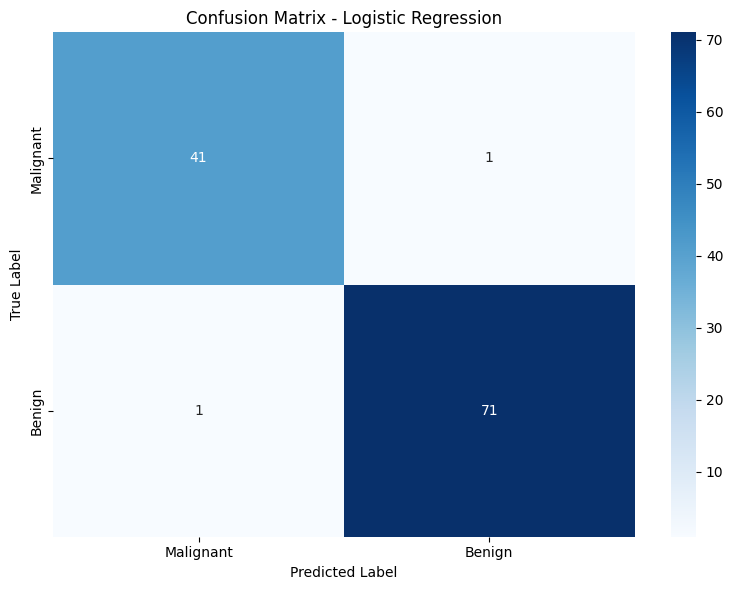

In [12]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 4. Model Evaluation
Testing the final model on held-out test data (114 samples).
- 41/42 malignant cases correctly identified
- 71/72 benign cases correctly identified
- 1 missed cancer case (false negative)
- 1 false alarm (false positive)

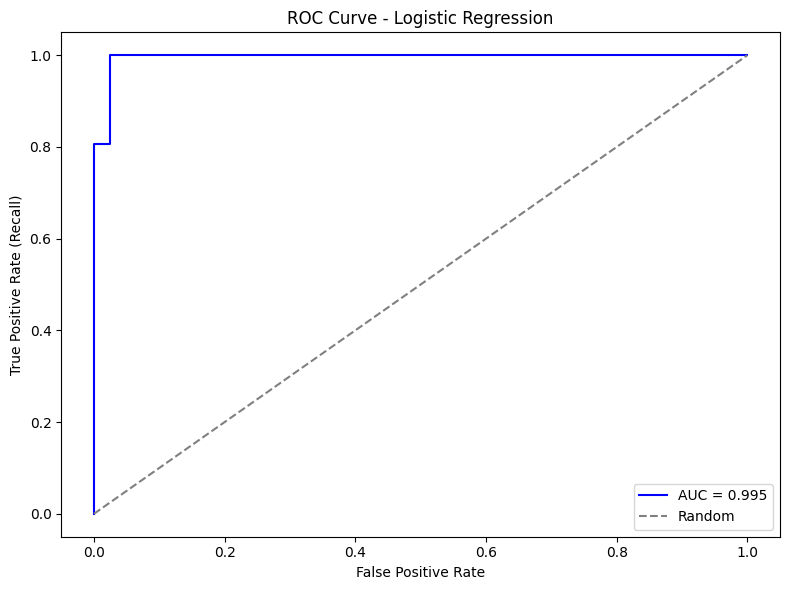

In [13]:
# ROC-curve
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.tight_layout()
plt.show()

## 5. ROC Curve
AUC = 0.995. Near perfect ability to distinguish malignant from benign tumors.
The diagonal dashed line represents random guessing (AUC = 0.5).

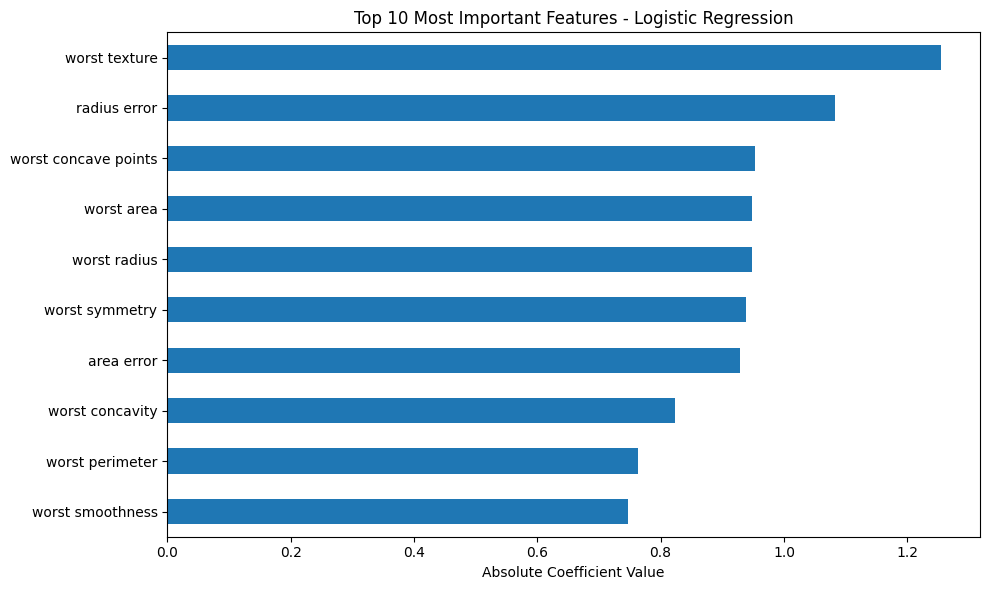

In [14]:
# Feature importance via logistic regression coefficients
feature_importance = pd.Series(
    np.abs(best_model.named_steps['model'].coef_[0]),
    index=data.feature_names
).sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh')
plt.title('Top 10 Most Important Features - Logistic Regression')
plt.xlabel('Absolute Coefficient Value')
plt.tight_layout()
plt.show()

## 6. Feature Importance
Top 10 most influential features based on logistic regression coefficients.
Worst-values dominate (8/10). Extreme cell measurements are more 
diagnostically useful than averages, consistent with EDA findings.